In [17]:
from sklearn.datasets import fetch_openml
import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import torch
from sklearn.base import BaseEstimator
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier

mnist = fetch_openml("mnist_784", version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [18]:
X, y = mnist["data"], mnist["target"]
print(torch.cuda.is_available())

False


<class 'numpy.ndarray'>


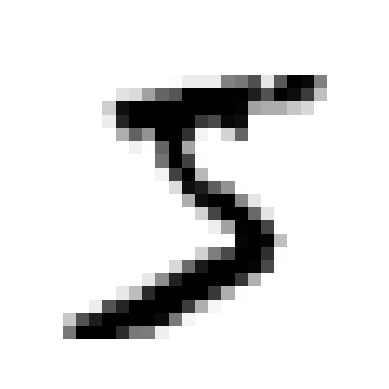

In [19]:
if (type(X) != "numpy.ndarray"):
    X = X.to_numpy()
print(type(X))
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [20]:
y[0]

'5'

In [21]:
y = y.astype(np.uint8)

In [22]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [23]:
y_train_5 = y_train == 5
y_test_5 = y_test == 5
print(np.unique(y_train_5))

[False  True]


In [24]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [25]:
sgd_clf.predict([some_digit])

array([ True])

### Implementing Cross-Validation

In [26]:
skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
for train_idx, test_idx in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_idx]
    y_train_folds = y_train_5[train_idx]
    X_test_folds = X_train[test_idx]
    y_test_folds = y_train_5[test_idx]
clone_clf.fit(X_train_folds, y_train_folds)
y_pred = clone_clf.predict(X_test_folds)
n_correct = sum(y_pred == y_test_folds)
print(n_correct / len(y_pred))

0.96785


In [33]:
scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3)

print(scores)
print(scores.mean())

[0.95035 0.96035 0.9604 ]
0.9570333333333334


In [36]:
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)


never_5_clf = Never5Classifier()
y_train_pred = cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

### Implementing Confusion Matrix

In [39]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [38]:
print(y_train_5.shape)
print(y_train_pred.shape)

(60000,)
(3,)


In [41]:
y_train_perfect_prediction = y_train_5
confusion_matrix(y_train_5, y_train_perfect_prediction)

array([[54579,     0],
       [    0,  5421]])

In [46]:
from sklearn.metrics import precision_score,recall_score
precision = precision_score(y_train_5,y_train_pred)

In [47]:
recall = recall_score(y_train_5,y_train_pred)

In [49]:
f1 = (2*precision*recall)/(precision+recall)
print(f1)

0.7325171197343846


In [50]:
from sklearn.metrics import f1_score

f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [52]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [55]:
threshold = 8000
y_some_digit_pred = y_scores > threshold
y_some_digit_pred

array([False])

In [56]:
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)

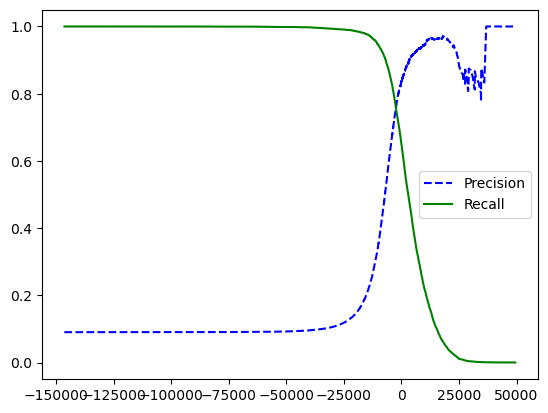

In [61]:
from sklearn.metrics import precision_recall_curve

precision, recall, threshold = precision_recall_curve(y_train_5, y_scores)


def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    [...]  # highlight the threshold, add the legend, axis label and grid


plot_precision_recall_vs_threshold(precision, recall, threshold)

plt.legend()
plt.show()